# Haryanvi Translation Notebook

This notebook includes Hindi-to-Haryanvi LLaMA fine-tuning and hyperparameter comparison.

In [1]:
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional
import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


@dataclass
class CombinedConfig:
    # -------- Authentication --------
    HF_TOKEN: Optional[str] = os.getenv("HF_TOKEN")

    # -------- Shared --------
    RANDOM_SEED: int = 42
    PROJECT_DIR: Path = Path(".")
    USE_GOOGLE_DRIVE: bool = True
    GOOGLE_DRIVE_ROOT: Path = Path("/content/drive/MyDrive/DSAI_translation")
    USE_LOCAL_RUNTIME_HF_CACHE: bool = True
    COLAB_LOCAL_CACHE_ROOT: Path = Path("/content/hf_cache")
    HF_HOME_DIR: Path = Path("combined_outputs/hf_home")
    HF_HUB_CACHE_DIR: Path = Path("combined_outputs/hf_hub_cache")
    TRANSFORMERS_CACHE_DIR: Path = Path("combined_outputs/transformers_cache")

    # -------- Text / LLM data --------
    HF_TEXT_REPO_ID: str = "Satyam-Srivastava/RDS"
    HF_TEXT_REPO_TYPE: str = "dataset"
    TXT_HINDI_FILE: str = "text_data/hindi1.txt"
    TXT_HARYANVI_FILE: str = "text_data/haryanvi1.txt"
    JSON_FILE: str = "text_data/hindi_haryanvi_dataset_5000.json"
    TEXT_MIN_WORDS: int = 3
    TEXT_MAX_WORDS: int = 25
    TEXT_TEST_SPLIT: float = 0.20
    TEXT_VAL_SPLIT: float = 0.50

    # -------- LLM fine-tuning --------
    LLM_MODEL_ID: str = "meta-llama/Meta-Llama-3.1-8B-Instruct"
    LLM_MAX_LENGTH: int = 192
    LLM_OUTPUT_ROOT: Path = Path("combined_outputs/llm")
    LLM_GENERATION_MAX_NEW_TOKENS: int = 128
    LLM_TEST_LIMIT: Optional[int] = None
    LLM_QUALITATIVE_HOLDOUT_SIZE: int = 25
    LLM_RUN_FINAL_TEST_EVAL: bool = True
    LLM_SKIP_FINISHED_EXPERIMENTS: bool = True
    LLM_EXPERIMENTS: List[Dict[str, Any]] = field(
        default_factory=lambda: [
            {
                "name": "baseline",
                "learning_rate": 2e-4,
                "num_train_epochs": 3,
                "per_device_train_batch_size": 4,
                "gradient_accumulation_steps": 4,
                "per_device_eval_batch_size": 4,
                "lora_r": 16,
                "lora_alpha": 32,
                "lora_dropout": 0.05,
                "warmup_steps": 50,
                "weight_decay": 0.00,
                "max_grad_norm": 0.30,
            },
            {
                "name": "lower_lr_longer",
                "learning_rate": 1e-4,
                "num_train_epochs": 4,
                "per_device_train_batch_size": 4,
                "gradient_accumulation_steps": 4,
                "per_device_eval_batch_size": 4,
                "lora_r": 16,
                "lora_alpha": 32,
                "lora_dropout": 0.05,
                "warmup_steps": 100,
                "weight_decay": 0.00,
                "max_grad_norm": 0.30,
            },
            {
                "name": "higher_rank",
                "learning_rate": 2e-4,
                "num_train_epochs": 3,
                "per_device_train_batch_size": 4,
                "gradient_accumulation_steps": 4,
                "per_device_eval_batch_size": 4,
                "lora_r": 32,
                "lora_alpha": 64,
                "lora_dropout": 0.10,
                "warmup_steps": 50,
                "weight_decay": 0.00,
                "max_grad_norm": 0.30,
            },
            {
                "name": "higher_dropout_reg",
                "learning_rate": 2e-4,
                "num_train_epochs": 3,
                "per_device_train_batch_size": 4,
                "gradient_accumulation_steps": 4,
                "per_device_eval_batch_size": 4,
                "lora_r": 16,
                "lora_alpha": 32,
                "lora_dropout": 0.15,
                "warmup_steps": 50,
                "weight_decay": 0.01,
                "max_grad_norm": 0.30,
            },
            {
                "name": "stronger_grad_clip",
                "learning_rate": 2e-4,
                "num_train_epochs": 3,
                "per_device_train_batch_size": 4,
                "gradient_accumulation_steps": 4,
                "per_device_eval_batch_size": 4,
                "lora_r": 16,
                "lora_alpha": 32,
                "lora_dropout": 0.05,
                "warmup_steps": 50,
                "weight_decay": 0.00,
                "max_grad_norm": 0.15,
            },
            {
                "name": "longer_context_256",
                "learning_rate": 2e-4,
                "num_train_epochs": 3,
                "per_device_train_batch_size": 4,
                "gradient_accumulation_steps": 4,
                "per_device_eval_batch_size": 4,
                "lora_r": 16,
                "lora_alpha": 32,
                "lora_dropout": 0.05,
                "warmup_steps": 50,
                "weight_decay": 0.00,
                "max_grad_norm": 0.30,
                "llm_max_length": 256,
            },
        ]
    )

    # -------- Execution toggles --------
    RUN_LLM_EXPERIMENTS: bool = True
    RUN_LLM_INTERACTIVE_TEST: bool = True


CFG = CombinedConfig()

def configure_project_paths(base_dir: Path, cache_root: Optional[Path] = None) -> None:
    base_dir = Path(base_dir)
    cache_root = Path(cache_root) if cache_root is not None else (base_dir / "combined_outputs")
    CFG.PROJECT_DIR = base_dir
    CFG.LLM_OUTPUT_ROOT = base_dir / "combined_outputs" / "llm"
    CFG.HF_HOME_DIR = cache_root / "hf_home"
    CFG.HF_HUB_CACHE_DIR = cache_root / "hf_hub_cache"
    CFG.TRANSFORMERS_CACHE_DIR = cache_root / "transformers_cache"

    for path_attr in [
        "PROJECT_DIR",
        "LLM_OUTPUT_ROOT",
        "HF_HOME_DIR",
        "HF_HUB_CACHE_DIR",
        "TRANSFORMERS_CACHE_DIR",
    ]:
        path_value = getattr(CFG, path_attr)
        if isinstance(path_value, Path):
            path_value.mkdir(parents=True, exist_ok=True)

    # Keep model/download caches configurable so Colab can use fast local disk.
    os.environ["HF_HOME"] = str(CFG.HF_HOME_DIR)
    os.environ["HF_HUB_CACHE"] = str(CFG.HF_HUB_CACHE_DIR)
    os.environ["TRANSFORMERS_CACHE"] = str(CFG.TRANSFORMERS_CACHE_DIR)


try:
    from google.colab import drive as google_drive

    IN_COLAB = True
except Exception:
    google_drive = None
    IN_COLAB = False

if IN_COLAB and CFG.USE_GOOGLE_DRIVE:
    # Mount once so checkpoints and downloaded assets survive runtime disconnects.
    google_drive.mount("/content/drive", force_remount=False)
    cache_root = CFG.COLAB_LOCAL_CACHE_ROOT if CFG.USE_LOCAL_RUNTIME_HF_CACHE else (CFG.GOOGLE_DRIVE_ROOT / "combined_outputs")
    configure_project_paths(CFG.GOOGLE_DRIVE_ROOT, cache_root=cache_root)
    print(f"Google Drive mounted. Saving checkpoints and outputs to: {CFG.PROJECT_DIR}")
    print(f"Hugging Face caches stored at: {CFG.HF_HOME_DIR.parent}")
else:
    configure_project_paths(CFG.PROJECT_DIR.resolve())
    print(f"Saving checkpoints and outputs to local path: {CFG.PROJECT_DIR}")

print("Top-level config loaded.")
print("Adjust CFG before running expensive cells if needed.")
print(asdict(CFG))

Mounted at /content/drive
Google Drive mounted. Saving checkpoints and outputs to: /content/drive/MyDrive/DSAI_translation
Hugging Face caches stored at: /content/hf_cache
Top-level config loaded.
Adjust CFG before running expensive cells if needed.
{'HF_TOKEN': None, 'RANDOM_SEED': 42, 'PROJECT_DIR': PosixPath('/content/drive/MyDrive/DSAI_translation'), 'USE_GOOGLE_DRIVE': True, 'GOOGLE_DRIVE_ROOT': PosixPath('/content/drive/MyDrive/DSAI_translation'), 'USE_LOCAL_RUNTIME_HF_CACHE': True, 'COLAB_LOCAL_CACHE_ROOT': PosixPath('/content/hf_cache'), 'HF_HOME_DIR': PosixPath('/content/hf_cache/hf_home'), 'HF_HUB_CACHE_DIR': PosixPath('/content/hf_cache/hf_hub_cache'), 'TRANSFORMERS_CACHE_DIR': PosixPath('/content/hf_cache/transformers_cache'), 'HF_TEXT_REPO_ID': 'Satyam-Srivastava/RDS', 'HF_TEXT_REPO_TYPE': 'dataset', 'TXT_HINDI_FILE': 'text_data/hindi1.txt', 'TXT_HARYANVI_FILE': 'text_data/haryanvi1.txt', 'JSON_FILE': 'text_data/hindi_haryanvi_dataset_5000.json', 'TEXT_MIN_WORDS': 3, 'TEXT

In [2]:
# Run this once per fresh environment.
!pip install -q --upgrade pip setuptools wheel
!pip install -q datasets pandas scikit-learn trl peft bitsandbytes accelerate transformers huggingface_hub sacrebleu matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 78.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [3]:
import copy
import gc
import json
import platform
import random
import re
import shutil
import sys
import warnings

import datasets as datasets_lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import sacrebleu
import torch
import transformers
import trl
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import hf_hub_download
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from sacrebleu.metrics import BLEU, CHRF
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    default_data_collator,
)
from trl import SFTConfig, SFTTrainer

warnings.filterwarnings("ignore")


def resolve_hf_token(seed_value: Optional[str]) -> Optional[str]:
    if seed_value:
        return seed_value
    env_token = os.getenv("HF_TOKEN")
    if env_token:
        return env_token
    try:
        from google.colab import userdata

        colab_token = userdata.get("HF_TOKEN")
        if colab_token:
            return colab_token
    except Exception:
        pass
    return None


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


CFG.HF_TOKEN = resolve_hf_token(CFG.HF_TOKEN)
if not CFG.HF_TOKEN:
    raise ValueError("Set HF_TOKEN in the environment or Colab userdata before downloading gated assets.")

set_seed(CFG.RANDOM_SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
IS_BF16_CAPABLE = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
IS_A100 = "A100" in GPU_NAME.upper()

print(f"Device: {GPU_NAME}")
print(f"BF16 capable: {IS_BF16_CAPABLE}")
print(f"A100 detected: {IS_A100}")

Device: NVIDIA A100-SXM4-40GB
BF16 capable: True
A100 detected: True


## LLaMA Fine-Tuning And Hyperparameter Comparison

The next cells:
- download and clean the text dataset,
- tokenize it for LLaMA chat-format supervised fine-tuning,
- run each experiment in `CFG.LLM_EXPERIMENTS`,
- save per-experiment validation predictions and metrics,
- keep one fixed qualitative holdout for manual review,
- evaluate the final selected model on the test split.

In [4]:
print("--- Loading and cleaning Hindi/Haryanvi text data ---")

hindi_txt_path = hf_hub_download(
    repo_id=CFG.HF_TEXT_REPO_ID,
    filename=CFG.TXT_HINDI_FILE,
    repo_type=CFG.HF_TEXT_REPO_TYPE,
    token=CFG.HF_TOKEN,
)
haryanvi_txt_path = hf_hub_download(
    repo_id=CFG.HF_TEXT_REPO_ID,
    filename=CFG.TXT_HARYANVI_FILE,
    repo_type=CFG.HF_TEXT_REPO_TYPE,
    token=CFG.HF_TOKEN,
)
json_path = hf_hub_download(
    repo_id=CFG.HF_TEXT_REPO_ID,
    filename=CFG.JSON_FILE,
    repo_type=CFG.HF_TEXT_REPO_TYPE,
    token=CFG.HF_TOKEN,
)

with open(hindi_txt_path, "r", encoding="utf-8") as f:
    hindi_lines = [line.strip() for line in f if line.strip()]
with open(haryanvi_txt_path, "r", encoding="utf-8") as f:
    haryanvi_lines = [line.strip() for line in f if line.strip()]

min_len = min(len(hindi_lines), len(haryanvi_lines))
df_txt = pd.DataFrame(
    {
        "hindi": hindi_lines[:min_len],
        "haryanvi": haryanvi_lines[:min_len],
    }
)

with open(json_path, "r", encoding="utf-8") as f:
    json_data = json.load(f)

df_json = pd.DataFrame(json_data).rename(columns={"Hindi": "hindi", "Haryanvi": "haryanvi"})
df_text = pd.concat([df_txt, df_json], ignore_index=True)
df_text = df_text.dropna(subset=["hindi", "haryanvi"]).drop_duplicates().reset_index(drop=True)

df_text["hindi"] = df_text["hindi"].astype(str).str.strip()
df_text["haryanvi"] = df_text["haryanvi"].astype(str).str.strip()
df_text["hindi_len"] = df_text["hindi"].str.split().str.len()
df_text = df_text[
    (df_text["hindi_len"] >= CFG.TEXT_MIN_WORDS)
    & (df_text["hindi_len"] <= CFG.TEXT_MAX_WORDS)
].reset_index(drop=True)

train_df, temp_df = train_test_split(
    df_text,
    test_size=CFG.TEXT_TEST_SPLIT,
    random_state=CFG.RANDOM_SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=CFG.TEXT_VAL_SPLIT,
    random_state=CFG.RANDOM_SEED,
)

qualitative_holdout_size = min(CFG.LLM_QUALITATIVE_HOLDOUT_SIZE, max(0, len(val_df) - 1))
if qualitative_holdout_size > 0:
    qualitative_holdout_df = val_df.sample(
        n=qualitative_holdout_size,
        random_state=CFG.RANDOM_SEED,
    ).copy()
    validation_df = val_df.drop(index=qualitative_holdout_df.index).copy()
else:
    qualitative_holdout_df = val_df.iloc[0:0].copy()
    validation_df = val_df.copy()

for frame in [train_df, validation_df, qualitative_holdout_df, test_df]:
    frame.reset_index(drop=True, inplace=True)

text_dataset_dict = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df, preserve_index=False),
        "validation": Dataset.from_pandas(validation_df, preserve_index=False),
        "qualitative_holdout": Dataset.from_pandas(qualitative_holdout_df, preserve_index=False),
        "test": Dataset.from_pandas(test_df, preserve_index=False),
    }
)

print(
    f"Train: {len(train_df)} | Validation: {len(validation_df)} | "
    f"Qualitative Holdout: {len(qualitative_holdout_df)} | Test: {len(test_df)}"
)
qualitative_holdout_path = CFG.LLM_OUTPUT_ROOT / "qualitative_holdout.csv"
qualitative_holdout_df.to_csv(qualitative_holdout_path, index=False)
print(f"Saved fixed qualitative holdout: {qualitative_holdout_path}")
display(qualitative_holdout_df.head() if len(qualitative_holdout_df) else validation_df.head())

--- Loading and cleaning Hindi/Haryanvi text data ---


hindi1.txt: 0.00B [00:00, ?B/s]

haryanvi1.txt: 0.00B [00:00, ?B/s]

hindi_haryanvi_dataset_5000.json: 0.00B [00:00, ?B/s]

Train: 4011 | Validation: 476 | Qualitative Holdout: 25 | Test: 502
Saved fixed qualitative holdout: /content/drive/MyDrive/DSAI_translation/combined_outputs/llm/qualitative_holdout.csv


,hindi,haryanvi,hindi_len
0,मैं आज खेत में खरीदारी कर रहा है और आज बहुत ते...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,16
1,आज शहर में बच्चे मैदान में खेल रहे हैं। मेरा भ...,आज शहर में बच्चे मैदान में खेल रये से। मेरा भा...,15
2,स्कूल का शिक्षक शहर गया। वहाँ आज बाजार में भीड...,स्कूल का शिक्षक शहर गया। वाँ आज बाजार में भीड़...,11
3,आज स्कूल में आज मौसम बहुत अच्छा है। राम वहाँ ब...,आज स्कूल में आज मौसम घणा अच्छा सै। राम वाँ बात...,14
4,गाँव का किसान पार्क गया। वहाँ सब लोग काम में व...,गाँव का किसान पार्क गया। वाँ सब लोग काम में व्...,12


In [5]:
tokenizer = AutoTokenizer.from_pretrained(CFG.LLM_MODEL_ID, token=CFG.HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


def build_chat_prompt(hindi_text: str, haryanvi_text: Optional[str] = None) -> str:
    dialog = [
        {
            "role": "system",
            "content": (
                "You are a precise Hindi to Haryanvi (Bangru) translator. "
                "Convert the standard Hindi input into grammatically correct Haryanvi. "
                "Follow systematic lexical substitutions and morpho-syntactic rules."
            ),
        },
        {"role": "user", "content": hindi_text},
    ]
    if haryanvi_text is not None:
        dialog.append({"role": "assistant", "content": haryanvi_text})
        return tokenizer.apply_chat_template(dialog, tokenize=False)
    return tokenizer.apply_chat_template(dialog, tokenize=False, add_generation_prompt=True)


def tokenize_for_training(batch: Dict[str, List[str]], max_length: int) -> Dict[str, Any]:
    input_ids_list = []
    attention_masks_list = []
    labels_list = []

    for hindi, haryanvi in zip(batch["hindi"], batch["haryanvi"]):
        prompt_only = build_chat_prompt(hindi)
        full_prompt = build_chat_prompt(hindi, haryanvi)

        prompt_tokens = tokenizer(
            prompt_only,
            max_length=max_length,
            padding="max_length",
            truncation=True,
        )
        full_tokens = tokenizer(
            full_prompt,
            max_length=max_length,
            padding="max_length",
            truncation=True,
        )

        input_ids = full_tokens["input_ids"]
        attention_mask = full_tokens["attention_mask"]
        labels = input_ids.copy()
        prompt_length = int(sum(prompt_tokens["attention_mask"]))

        # Only supervise the assistant response; the prompt stays as context.
        for idx in range(min(prompt_length, len(labels))):
            labels[idx] = -100

        for idx, mask in enumerate(attention_mask):
            if mask == 0:
                labels[idx] = -100

        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)
        labels_list.append(labels)

    return {
        "input_ids": input_ids_list,
        "attention_mask": attention_masks_list,
        "labels": labels_list,
    }


TOKENIZED_DATASET_CACHE: Dict[int, DatasetDict] = {}


def get_tokenized_dataset(max_length: int) -> DatasetDict:
    normalized_max_length = int(max_length)
    if normalized_max_length not in TOKENIZED_DATASET_CACHE:
        # Cache tokenized splits so context-length experiments do not redo the same work.
        TOKENIZED_DATASET_CACHE[normalized_max_length] = text_dataset_dict.map(
            lambda batch: tokenize_for_training(batch, max_length=normalized_max_length),
            batched=True,
            remove_columns=list(text_dataset_dict["train"].column_names),
        )
    return TOKENIZED_DATASET_CACHE[normalized_max_length]


llm_ready_dataset = get_tokenized_dataset(CFG.LLM_MAX_LENGTH)

print("Tokenized datasets ready for training.")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Map:   0%|          | 0/4011 [00:00<?, ? examples/s]

Map:   0%|          | 0/476 [00:00<?, ? examples/s]

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Map:   0%|          | 0/502 [00:00<?, ? examples/s]

Tokenized datasets ready for training.


In [6]:
def estimate_token_length(text: str) -> int:
    return len(
        tokenizer(
            text,
            truncation=False,
            add_special_tokens=False,
        )["input_ids"]
    )


truncation_analysis_df = pd.DataFrame(
    {
        "split": ["train"] * len(train_df) + ["validation"] * len(validation_df) + ["test"] * len(test_df),
        "full_prompt_tokens": [
            estimate_token_length(build_chat_prompt(row.hindi, row.haryanvi))
            for row in train_df.itertuples(index=False)
        ]
        + [
            estimate_token_length(build_chat_prompt(row.hindi, row.haryanvi))
            for row in validation_df.itertuples(index=False)
        ]
        + [
            estimate_token_length(build_chat_prompt(row.hindi, row.haryanvi))
            for row in test_df.itertuples(index=False)
        ],
    }
)
truncation_analysis_df["is_truncated"] = truncation_analysis_df["full_prompt_tokens"] > CFG.LLM_MAX_LENGTH
truncation_summary_df = (
    truncation_analysis_df.groupby("split", as_index=False)
    .agg(
        samples=("full_prompt_tokens", "size"),
        avg_tokens=("full_prompt_tokens", "mean"),
        max_tokens=("full_prompt_tokens", "max"),
        truncated_samples=("is_truncated", "sum"),
    )
)
truncation_summary_df["truncated_pct"] = (
    100.0 * truncation_summary_df["truncated_samples"] / truncation_summary_df["samples"]
)
print("LLaMA truncation analysis against LLM_MAX_LENGTH")
display(truncation_summary_df)

sample_batch = llm_ready_dataset["train"][0]
supervised_token_ids = [
    token_id for token_id, label in zip(sample_batch["input_ids"], sample_batch["labels"]) if label != -100
]
ignored_positions = sum(label == -100 for label in sample_batch["labels"])
print(f"Assistant-only label check: ignored positions = {ignored_positions}, supervised tokens = {len(supervised_token_ids)}")
print("Decoded supervised assistant span:")
print(tokenizer.decode(supervised_token_ids, skip_special_tokens=False))

LLaMA truncation analysis against LLM_MAX_LENGTH


,split,samples,avg_tokens,max_tokens,truncated_samples,truncated_pct
0,test,502,133.366534,161,0,0.0
1,train,4011,134.160808,168,0,0.0
2,validation,476,134.094538,161,0,0.0


Assistant-only label check: ignored positions = 170, supervised tokens = 22
Decoded supervised assistant span:
मेरी बहन स्कूल गया। वाँ लोग घणा खुश से।<|eot_id|>


In [7]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF(word_order=2)


def normalize_for_compare(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def compute_translation_metrics(references: List[str], predictions: List[str]) -> Dict[str, float]:
    normalized_references = [normalize_for_compare(text) for text in references]
    normalized_predictions = [normalize_for_compare(text) for text in predictions]
    if not normalized_predictions:
        return {
            "exact_match_rate": float("nan"),
            "corpus_bleu": float("nan"),
            "corpus_chrf": float("nan"),
        }

    exact_match_rate = float(
        sum(pred == ref for pred, ref in zip(normalized_predictions, normalized_references))
        / len(normalized_predictions)
    )
    corpus_bleu = float(bleu_metric.corpus_score(normalized_predictions, [normalized_references]).score)
    corpus_chrf = float(chrf_metric.corpus_score(normalized_predictions, [normalized_references]).score)
    return {
        "exact_match_rate": exact_match_rate,
        "corpus_bleu": corpus_bleu,
        "corpus_chrf": corpus_chrf,
    }


def collect_package_versions() -> Dict[str, str]:
    return {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "trl": trl.__version__,
        "peft": peft.__version__,
        "datasets": datasets_lib.__version__,
        "sacrebleu": sacrebleu.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    }


def build_run_manifest(experiment_name: str, experiment_cfg: Dict[str, Any], experiment_max_length: int) -> Dict[str, Any]:
    return {
        "experiment_name": experiment_name,
        "seed": CFG.RANDOM_SEED,
        "model_id": CFG.LLM_MODEL_ID,
        "llm_max_length": int(experiment_max_length),
        "gpu_name": GPU_NAME,
        "is_bf16_capable": bool(IS_BF16_CAPABLE),
        "is_a100": bool(IS_A100),
        "package_versions": collect_package_versions(),
        "hyperparameters": dict(experiment_cfg),
        "python_executable": sys.executable,
    }


def build_quant_config() -> BitsAndBytesConfig:
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if IS_BF16_CAPABLE else torch.float16,
    )


def load_base_llm():
    model = AutoModelForCausalLM.from_pretrained(
        CFG.LLM_MODEL_ID,
        quantization_config=build_quant_config(),
        device_map="auto",
        token=CFG.HF_TOKEN,
        attn_implementation="sdpa",
    )
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)
    return model


def attach_lora_adapter(model, experiment_cfg: Dict[str, Any]):
    peft_config = LoraConfig(
        r=experiment_cfg["lora_r"],
        lora_alpha=experiment_cfg["lora_alpha"],
        lora_dropout=experiment_cfg["lora_dropout"],
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()
    return model


def generate_translation(model, inference_tokenizer, hindi_text: str) -> str:
    prompt = build_chat_prompt(hindi_text)
    inputs = inference_tokenizer(prompt, return_tensors="pt").to(model.device)

    terminators = [inference_tokenizer.eos_token_id]
    eot_id = inference_tokenizer.convert_tokens_to_ids("<|eot_id|>")
    if eot_id is not None:
        terminators.append(eot_id)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=CFG.LLM_GENERATION_MAX_NEW_TOKENS,
            eos_token_id=terminators,
            pad_token_id=inference_tokenizer.eos_token_id,
            do_sample=False,
            repetition_penalty=1.15,
        )

    full_text = inference_tokenizer.decode(outputs[0], skip_special_tokens=False)
    assistant_tag = "<|start_header_id|>assistant<|end_header_id|>\n\n"
    prediction = full_text.split(assistant_tag)[-1] if assistant_tag in full_text else full_text
    prediction = prediction.replace("<|eot_id|>", "").replace("<|eos_id|>", "").strip()
    prediction = prediction.split("\n")[0].split("|")[0].split("स्कीम")[0].strip()
    if "।" in prediction:
        prediction = prediction.split("।")[0].strip() + "।"
    return prediction


def run_predictions_on_dataframe(
    model,
    inference_tokenizer,
    dataset_df: pd.DataFrame,
    experiment_name: str,
    split_name: str,
) -> pd.DataFrame:
    prediction_rows = []
    working_df = dataset_df.copy()
    if split_name == "test" and CFG.LLM_TEST_LIMIT:
        working_df = working_df.head(CFG.LLM_TEST_LIMIT).copy()

    for sample_id, row in working_df.reset_index(drop=True).iterrows():
        prediction = generate_translation(model, inference_tokenizer, row["hindi"])
        reference = normalize_for_compare(row["haryanvi"])
        normalized_prediction = normalize_for_compare(prediction)
        prediction_rows.append(
            {
                "sample_id": sample_id,
                "split_name": split_name,
                "hindi": row["hindi"],
                "reference_haryanvi": row["haryanvi"],
                "prediction": prediction,
                "exact_match": normalized_prediction == reference,
                "sentence_chrf": float(chrf_metric.sentence_score(normalized_prediction, [reference]).score),
                "experiment_name": experiment_name,
            }
        )

    return pd.DataFrame(prediction_rows)


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def run_single_llm_experiment(experiment_cfg: Dict[str, Any]) -> Dict[str, Any]:
    experiment_name = experiment_cfg["name"]
    experiment_max_length = int(experiment_cfg.get("llm_max_length", CFG.LLM_MAX_LENGTH))
    experiment_dataset = get_tokenized_dataset(experiment_max_length)
    output_dir = CFG.LLM_OUTPUT_ROOT / experiment_name
    adapter_dir = output_dir / "adapter"
    validation_predictions_path = output_dir / "validation_predictions.csv"
    qualitative_predictions_path = output_dir / "qualitative_predictions.csv"
    log_history_path = output_dir / "training_log_history.csv"
    worst_cases_path = output_dir / "worst_validation_cases.csv"
    manifest_path = output_dir / "run_manifest.json"
    summary_path = output_dir / "summary.json"
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save both the sweep hyperparameters and a fuller run manifest for reproducibility.
    with open(output_dir / "hyperparameters.json", "w", encoding="utf-8") as f:
        json.dump(experiment_cfg, f, ensure_ascii=False, indent=2)
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(build_run_manifest(experiment_name, experiment_cfg, experiment_max_length), f, ensure_ascii=False, indent=2)

    if CFG.LLM_SKIP_FINISHED_EXPERIMENTS and validation_predictions_path.exists() and qualitative_predictions_path.exists() and summary_path.exists():
        print(f"Skipping {experiment_name} because saved outputs already exist.")
        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)
        validation_predictions_df = pd.read_csv(validation_predictions_path)
        if "sentence_chrf" in validation_predictions_df.columns and not worst_cases_path.exists():
            validation_predictions_df.nsmallest(20, "sentence_chrf").to_csv(worst_cases_path, index=False)
        summary.setdefault("llm_max_length", experiment_max_length)
        summary["run_manifest_path"] = str(manifest_path)
        summary["worst_validation_cases_path"] = str(worst_cases_path)
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary, f, ensure_ascii=False, indent=2)
        summary["validation_predictions_df"] = validation_predictions_df
        summary["qualitative_predictions_df"] = pd.read_csv(qualitative_predictions_path)
        return summary

    model = load_base_llm()
    model = attach_lora_adapter(model, experiment_cfg)

    training_args = SFTConfig(
        output_dir=str(output_dir / "checkpoints"),
        per_device_train_batch_size=experiment_cfg["per_device_train_batch_size"],
        gradient_accumulation_steps=experiment_cfg["gradient_accumulation_steps"],
        per_device_eval_batch_size=experiment_cfg["per_device_eval_batch_size"],
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        logging_steps=10,
        learning_rate=experiment_cfg["learning_rate"],
        warmup_steps=experiment_cfg["warmup_steps"],
        num_train_epochs=experiment_cfg["num_train_epochs"],
        lr_scheduler_type="cosine",
        max_grad_norm=experiment_cfg.get("max_grad_norm", 0.3),
        weight_decay=experiment_cfg.get("weight_decay", 0.0),
        optim="paged_adamw_32bit",
        bf16=IS_BF16_CAPABLE,
        fp16=torch.cuda.is_available() and not IS_BF16_CAPABLE,
        report_to="none",
        remove_unused_columns=False,
        group_by_length=True,
        seed=CFG.RANDOM_SEED,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        max_length=experiment_max_length,
        dataset_text_field=None,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=experiment_dataset["train"],
        eval_dataset=experiment_dataset["validation"],
        processing_class=tokenizer,
        data_collator=default_data_collator,
    )

    train_result = trainer.train()
    eval_metrics = trainer.evaluate()
    pd.DataFrame(trainer.state.log_history).to_csv(log_history_path, index=False)

    trainer.model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    validation_predictions_df = run_predictions_on_dataframe(
        trainer.model,
        tokenizer,
        validation_df,
        experiment_name,
        "validation",
    )
    qualitative_predictions_df = run_predictions_on_dataframe(
        trainer.model,
        tokenizer,
        qualitative_holdout_df,
        experiment_name,
        "qualitative_holdout",
    )
    validation_predictions_df.to_csv(validation_predictions_path, index=False)
    qualitative_predictions_df.to_csv(qualitative_predictions_path, index=False)
    # Keep a small failure-analysis table for quick review after each run.
    validation_predictions_df.nsmallest(20, "sentence_chrf").to_csv(worst_cases_path, index=False)

    validation_metrics = compute_translation_metrics(
        validation_predictions_df["reference_haryanvi"].tolist(),
        validation_predictions_df["prediction"].tolist(),
    )
    qualitative_metrics = compute_translation_metrics(
        qualitative_predictions_df["reference_haryanvi"].tolist(),
        qualitative_predictions_df["prediction"].tolist(),
    )

    summary = {
        "experiment_name": experiment_name,
        "eval_loss": float(eval_metrics.get("eval_loss", float("nan"))),
        "train_runtime": float(train_result.metrics.get("train_runtime", float("nan"))),
        "train_samples_per_second": float(train_result.metrics.get("train_samples_per_second", float("nan"))),
        "validation_exact_match_rate": float(validation_metrics["exact_match_rate"]),
        "validation_corpus_bleu": float(validation_metrics["corpus_bleu"]),
        "validation_corpus_chrf": float(validation_metrics["corpus_chrf"]),
        "qualitative_exact_match_rate": float(qualitative_metrics["exact_match_rate"]),
        "qualitative_corpus_bleu": float(qualitative_metrics["corpus_bleu"]),
        "qualitative_corpus_chrf": float(qualitative_metrics["corpus_chrf"]),
        "adapter_dir": str(adapter_dir),
        "llm_max_length": experiment_max_length,
        "weight_decay": float(experiment_cfg.get("weight_decay", 0.0)),
        "max_grad_norm": float(experiment_cfg.get("max_grad_norm", 0.3)),
        "lora_dropout": float(experiment_cfg.get("lora_dropout", 0.0)),
        "training_log_history_path": str(log_history_path),
        "run_manifest_path": str(manifest_path),
        "worst_validation_cases_path": str(worst_cases_path),
    }
    summary.update(experiment_cfg)

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    summary["validation_predictions_df"] = validation_predictions_df
    summary["qualitative_predictions_df"] = qualitative_predictions_df

    del trainer
    del model
    cleanup_cuda()
    return summary


def load_adapter_for_inference(adapter_dir: Path):
    base_model = AutoModelForCausalLM.from_pretrained(
        CFG.LLM_MODEL_ID,
        quantization_config=build_quant_config(),
        device_map="auto",
        token=CFG.HF_TOKEN,
        attn_implementation="sdpa",
    )
    merged_model = PeftModel.from_pretrained(base_model, str(adapter_dir))
    merged_model.eval()
    return merged_model

In [8]:
if not CFG.RUN_LLM_EXPERIMENTS:
    print("Skipping LLM experiments because CFG.RUN_LLM_EXPERIMENTS is False.")
else:
    experiment_summaries = []
    comparison_df = qualitative_holdout_df.copy().reset_index(drop=True)
    comparison_df.insert(0, "sample_id", comparison_df.index)
    comparison_df.rename(columns={"haryanvi": "reference_haryanvi"}, inplace=True)

    for experiment_cfg in CFG.LLM_EXPERIMENTS:
        print(f"\n=== Running experiment: {experiment_cfg['name']} ===")
        summary = run_single_llm_experiment(experiment_cfg)
        qualitative_predictions_df = summary.pop("qualitative_predictions_df")
        summary.pop("validation_predictions_df", None)
        experiment_summaries.append(summary)
        comparison_df = comparison_df.merge(
            qualitative_predictions_df[["sample_id", "prediction"]].rename(
                columns={"prediction": f"prediction__{experiment_cfg['name']}"}
            ),
            on="sample_id",
            how="left",
        )

    llm_summary_df = pd.DataFrame(experiment_summaries).sort_values(
        by=["validation_corpus_chrf", "validation_corpus_bleu", "validation_exact_match_rate"],
        ascending=[False, False, False],
    )
    llm_summary_path = CFG.LLM_OUTPUT_ROOT / "experiment_summary.csv"
    llm_compare_path = CFG.LLM_OUTPUT_ROOT / "manual_comparison.csv"
    llm_summary_df.to_csv(llm_summary_path, index=False)
    comparison_df.to_csv(llm_compare_path, index=False)

    print(f"Saved summary: {llm_summary_path}")
    print(f"Saved manual comparison table: {llm_compare_path}")
    display(llm_summary_df)
    display(comparison_df.head(20))
    best_worst_cases_path = Path(llm_summary_df.iloc[0]["worst_validation_cases_path"])
    if best_worst_cases_path.exists():
        print(f"Worst validation examples for the current best run: {best_worst_cases_path}")
        display(pd.read_csv(best_worst_cases_path).head(20))


=== Running experiment: baseline ===


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

...

Saved summary: /content/drive/MyDrive/DSAI_translation/combined_outputs/llm/experiment_summary.csv
Saved manual comparison table: /content/drive/MyDrive/DSAI_translation/combined_outputs/llm/manual_comparison.csv


,experiment_name,eval_loss,train_runtime,train_samples_per_second,validation_exact_match_rate,validation_corpus_bleu,validation_corpus_chrf,qualitative_exact_match_rate,qualitative_corpus_bleu,qualitative_corpus_chrf,...,worst_validation_cases_path,name,learning_rate,num_train_epochs,per_device_train_batch_size,gradient_accumulation_steps,per_device_eval_batch_size,lora_r,lora_alpha,warmup_steps
1,lower_lr_longer,0.003241,3082.5800,5.205,0.504202,71.759715,77.649030,0.56,74.282314,79.5709,...,/content/drive/MyDrive/DSAI_translation/combin...,lower_lr_longer,0.0001,4,4,4,4,16,32,100
5,longer_context_256,0.003891,2339.0158,5.144,0.504202,71.761635,77.648315,0.56,74.282314,79.5709,...,/content/drive/MyDrive/DSAI_translation/combin...,longer_context_256,0.0002,3,4,4,4,16,32,50
3,higher_dropout_reg,0.003432,2312.7892,5.203,0.504202,71.747565,77.640607,0.56,74.282314,79.5709,...,/content/drive/MyDrive/DSAI_translation/combin...,higher_dropout_reg,0.0002,3,4,4,4,16,32,50
4,stronger_grad_clip,0.004164,2328.8853,5.167,0.504202,71.747565,77.640607,0.56,74.282314,79.5709,...,/content/drive/MyDrive/DSAI_translation/combin...,stronger_grad_clip,0.0002,3,4,4,4,16,32,50
2,higher_rank,0.004269,2334.3503,5.155,0.504202,71.747565,77.639930,0.56,74.282314,79.5709,...,/content/drive/MyDrive/DSAI_translation/combin...,higher_rank,0.0002,3,4,4,4,32,64,50
0,baseline,0.004359,2303.9847,5.223,0.504202,71.745116,77.628751,0.56,74.282314,79.5709,...,/content/drive/MyDrive/DSAI_translation/combin...,baseline,0.0002,3,4,4,4,16,32,50


,sample_id,hindi,reference_haryanvi,hindi_len,prediction__baseline,prediction__lower_lr_longer,prediction__higher_rank,prediction__higher_dropout_reg,prediction__stronger_grad_clip,prediction__longer_context_256
0,0,मैं आज खेत में खरीदारी कर रहा है और आज बहुत ते...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,16,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...,मैं आज खेत में खरीदारी कर रया सै और आज घणा तेज...
1,1,आज शहर में बच्चे मैदान में खेल रहे हैं। मेरा भ...,आज शहर में बच्चे मैदान में खेल रये से। मेरा भा...,15,आज शहर में बच्चे मैदान में खेल रये से।,आज शहर में बच्चे मैदान में खेल रये से।,आज शहर में बच्चे मैदान में खेल रये से।,आज शहर में बच्चे मैदान में खेल रये से।,आज शहर में बच्चे मैदान में खेल रये से।,आज शहर में बच्चे मैदान में खेल रये से।
2,2,स्कूल का शिक्षक शहर गया। वहाँ आज बाजार में भीड...,स्कूल का शिक्षक शहर गया। वाँ आज बाजार में भीड़...,11,स्कूल का शिक्षक शहर गया।,स्कूल का शिक्षक शहर गया।,स्कूल का शिक्षक शहर गया।,स्कूल का शिक्षक शहर गया।,स्कूल का शिक्षक शहर गया।,स्कूल का शिक्षक शहर गया।
3,3,आज स्कूल में आज मौसम बहुत अच्छा है। राम वहाँ ब...,आज स्कूल में आज मौसम घणा अच्छा सै। राम वाँ बात...,14,आज स्कूल में आज मौसम घणा अच्छा सै।,आज स्कूल में आज मौसम घणा अच्छा सै।,आज स्कूल में आज मौसम घणा अच्छा सै।,आज स्कूल में आज मौसम घणा अच्छा सै।,आज स्कूल में आज मौसम घणा अच्छा सै।,आज स्कूल में आज मौसम घणा अच्छा सै।
4,4,गाँव का किसान पार्क गया। वहाँ सब लोग काम में व...,गाँव का किसान पार्क गया। वाँ सब लोग काम में व्...,12,गाँव का किसान पार्क गया।,गाँव का किसान पार्क गया।,गाँव का किसान पार्क गया।,गाँव का किसान पार्क गया।,गाँव का किसान पार्क गया।,गाँव का किसान पार्क गया।
5,5,एक लड़का शहर में पढ़ रहा है।,एक छोरा शहर में पढ़ रया सै।,7,एक छोरा शहर में पढ़ रया सै।,एक छोरा शहर में पढ़ रया सै।,एक छोरा शहर में पढ़ रया सै।,एक छोरा शहर में पढ़ रया सै।,एक छोरा शहर में पढ़ रया सै।,एक छोरा शहर में पढ़ रया सै।
6,6,मेरी बहन आज मेले में काम कर रहा है और आज स्कूल...,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...,15,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...,मेरी बहन आज मेले में काम कर रया सै और आज स्कूल...
7,7,गाँव का किसान आज दुकान में सो रहा है और आज मौस...,गाँव का किसान आज दुकान में सो रया सै और आज मौस...,15,गाँव का किसान आज दुकान में सो रया सै और आज मौस...,गाँव का किसान आज दुकान में सो रया सै और आज मौस...,गाँव का किसान आज दुकान में सो रया सै और आज मौस...,गाँव का किसान आज दुकान में सो रया सै और आज मौस...,गाँव का किसान आज दुकान में सो रया सै और आज मौस...,गाँव का किसान आज दुकान में सो रया सै और आज मौस...
8,8,स्कूल का शिक्षक बाज़ार में काम कर रहा है।,स्कूल का शिक्षक बाज़ार में काम कर रया सै।,9,स्कूल का शिक्षक बाज़ार में काम कर रया सै।,स्कूल का शिक्षक बाज़ार में काम कर रया सै।,स्कूल का शिक्षक बाज़ार में काम कर रया सै।,स्कूल का शिक्षक बाज़ार में काम कर रया सै।,स्कूल का शिक्षक बाज़ार में काम कर रया सै।,स्कूल का शिक्षक बाज़ार में काम कर रया सै।
9,9,मेरी बहन आज बाज़ार में इंतजार कर रहा है और आज ...,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...,15,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...,मेरी बहन आज बाज़ार में इंतजार कर रया सै और आज ...


Worst validation examples for the current best run: /content/drive/MyDrive/DSAI_translation/combined_outputs/llm/lower_lr_longer/worst_validation_cases.csv


,sample_id,split_name,hindi,reference_haryanvi,prediction,exact_match,sentence_chrf,experiment_name
0,57,validation,मैं घर गया। वहाँ आज बहुत तेज हवा चल रही है।,मैं घर गया। वाँ आज घणा तेज हवा चल रयी सै।,मैं घर गया।,False,26.968877,lower_lr_longer
1,243,validation,हम घर गया। वहाँ आज मौसम बहुत अच्छा है।,हम घर गया। वाँ आज मौसम घणा अच्छा सै।,हम घर गया।,False,27.412686,lower_lr_longer
2,289,validation,राम घर गया। वहाँ आज स्कूल में छुट्टी है।,राम घर गया। वाँ आज स्कूल में छुट्टी सै।,राम घर गया।,False,28.510651,lower_lr_longer
3,334,validation,हम खेत गया। वहाँ आज स्कूल में छुट्टी है।,हम खेत गया। वाँ आज स्कूल में छुट्टी सै।,हम खेत गया।,False,28.510651,lower_lr_longer
4,182,validation,मैं शहर गया। वहाँ आज बहुत तेज हवा चल रही है।,मैं शहर गया। वाँ आज घणा तेज हवा चल रयी सै।,मैं शहर गया।,False,29.177277,lower_lr_longer
5,359,validation,सीमा घर गया। वहाँ सब लोग काम में व्यस्त हैं।,सीमा घर गया। वाँ सब लोग काम में व्यस्त से।,सीमा घर गया।,False,29.181456,lower_lr_longer
6,179,validation,सीमा खेत गया। वहाँ बच्चे मैदान में खेल रहे हैं।,सीमा खेत गया। वाँ बच्चे मैदान में खेल रये से।,सीमा खेत गया।,False,29.866972,lower_lr_longer
7,44,validation,राम घर गया। वहाँ आज मौसम बहुत अच्छा है।,राम घर गया। वाँ आज मौसम घणा अच्छा सै।,राम घर गया।,False,29.910718,lower_lr_longer
8,404,validation,राम गाँव गया। वहाँ सब लोग काम में व्यस्त हैं।,राम गाँव गया। वाँ सब लोग काम में व्यस्त से।,राम गाँव गया।,False,31.181229,lower_lr_longer
9,105,validation,सीमा खेत गया। वहाँ आज बहुत तेज हवा चल रही है।,सीमा खेत गया। वाँ आज घणा तेज हवा चल रयी सै।,सीमा खेत गया।,False,31.220906,lower_lr_longer


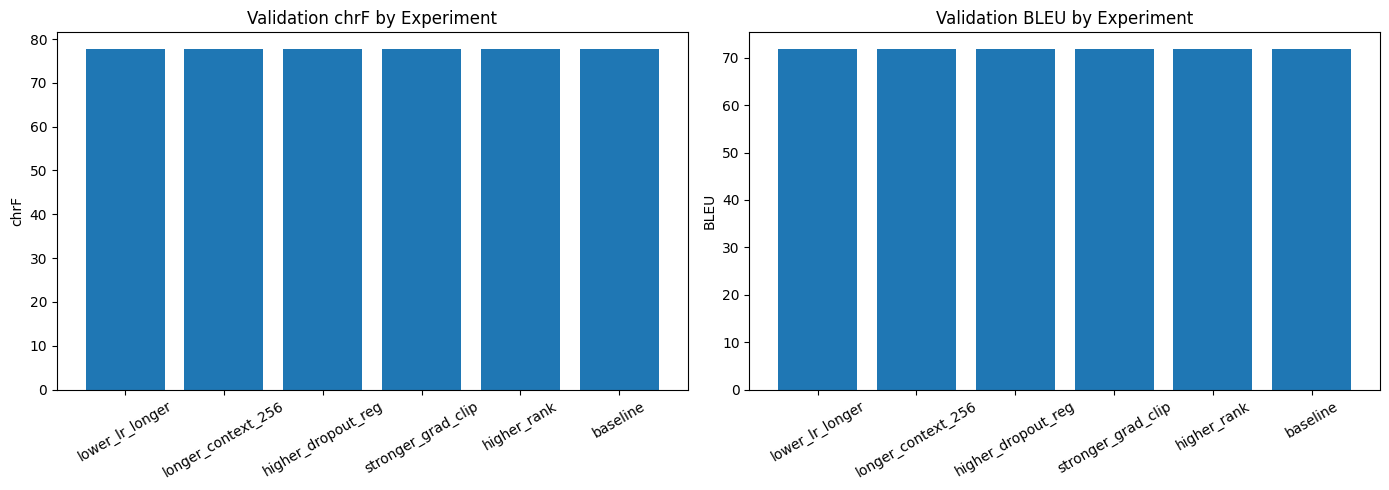

In [9]:
if CFG.RUN_LLM_EXPERIMENTS:
    plot_df = llm_summary_df.copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(plot_df["experiment_name"], plot_df["validation_corpus_chrf"])
    axes[0].set_title("Validation chrF by Experiment")
    axes[0].set_ylabel("chrF")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(plot_df["experiment_name"], plot_df["validation_corpus_bleu"])
    axes[1].set_title("Validation BLEU by Experiment")
    axes[1].set_ylabel("BLEU")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping LLaMA plots because experiments were not run.")

In [ ]:
if CFG.RUN_LLM_INTERACTIVE_TEST and CFG.RUN_LLM_EXPERIMENTS:
    best_experiment_name = llm_summary_df.iloc[0]["experiment_name"]
    best_adapter_dir = Path(llm_summary_df.iloc[0]["adapter_dir"])
    print(f"Best experiment by validation corpus chrF: {best_experiment_name}")

    base_inference_model = load_base_llm()
    finetuned_inference_model = load_adapter_for_inference(best_adapter_dir)

    demo_sentences = [
        "मैं आज बाजार जा रहा हूँ।",
        "क्या तुम कल स्कूल जाओगे?",
        "यह किताब मेरी है, इसे मत छूना।",
    ]

    for sentence in demo_sentences:
        print(f"Standard Hindi: {sentence}")
        print(f"Base Model Output:       {generate_translation(base_inference_model, tokenizer, sentence)}")
        print(f"Fine-Tuned Model Output: {generate_translation(finetuned_inference_model, tokenizer, sentence)}\n")

    # Uncomment to archive and download the best fine-tuned adapter.
    best_adapter_archive = CFG.LLM_OUTPUT_ROOT / f"{best_experiment_name}_adapter"
    shutil.make_archive(str(best_adapter_archive), "zip", best_adapter_dir)
    try:
        from google.colab import files
        files.download(f"{best_adapter_archive}.zip")
    except Exception:
        print(f"Created adapter archive: {best_adapter_archive}.zip")

    if CFG.LLM_RUN_FINAL_TEST_EVAL:
        final_test_predictions_df = run_predictions_on_dataframe(
            finetuned_inference_model,
            tokenizer,
            test_df,
            best_experiment_name,
            "test",
        )
        final_test_predictions_path = CFG.LLM_OUTPUT_ROOT / "final_test_predictions.csv"
        final_test_summary_path = CFG.LLM_OUTPUT_ROOT / "final_test_summary.json"
        final_test_predictions_df.to_csv(final_test_predictions_path, index=False)
        final_test_metrics = compute_translation_metrics(
            final_test_predictions_df["reference_haryanvi"].tolist(),
            final_test_predictions_df["prediction"].tolist(),
        )
        with open(final_test_summary_path, "w", encoding="utf-8") as f:
            json.dump(
                {
                    "best_experiment_name": best_experiment_name,
                    "test_exact_match_rate": float(final_test_metrics["exact_match_rate"]),
                    "test_corpus_bleu": float(final_test_metrics["corpus_bleu"]),
                    "test_corpus_chrf": float(final_test_metrics["corpus_chrf"]),
                },
                f,
                ensure_ascii=False,
                indent=2,
            )
        print(f"Saved final test predictions: {final_test_predictions_path}")
        print(f"Saved final test summary: {final_test_summary_path}")

    del base_inference_model
    del finetuned_inference_model
    cleanup_cuda()
else:
    print("Interactive LLM test skipped.")

Best experiment by validation corpus chrF: lower_lr_longer


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Standard Hindi: मैं आज बाजार जा रहा हूँ।
Base Model Output:       मैं आज बाज़ार जा रहा हूँ।
Fine-Tuned Model Output: मैं आज बाजार जा रया सै।

Standard Hindi: क्या तुम कल स्कूल जाओगे?
Base Model Output:       तू कल स्कूल जावोग।
Fine-Tuned Model Output: क्या तुम कल स्कूल जाओगे

Standard Hindi: यह किताब मेरी है, इसे मत छूना।
Base Model Output:       इस बुक तुम्हारी नाहीं है, ईसे चूहना नहीं।
Fine-Tuned Model Output: यो किताब मेरी सै, इसे न छूना।



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>